# Experiment #1:

In this experiment, we will compare the performance of the selected techniques for modeling hierarchical taxonomies from textual data. The goal of this experiment is to find the best performing technique to generated taxonomies for a Knowledge Graph (KG). Therefore the generated triples will be integrated into an existing KG. As baseline model for KG recommender systems we use the current state of the art Graph Neural Network (GNN) model `KGIL`, which the code is available on [GitHub](https://github.com/shuyao-wang/KGIL).

**Data:**
We will use the `Amazon All Beauty` dataset. The dataset was published by the McAuley Lab from the University of California, San Diego and contains reviews split into train and test set and metadata of products from Amazon. We will use the latest version of the dataset from 2023. The dataset is for the public available on [HuggingFace]('https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023'). We load the 5-core version of the dataset. To shrink the computational and memory footprint further we filter the dataset to a 10-core version.

**Techniques:**
We will compare the following techniques:
- Hierarchical topic modeling. _This technique is called Topic modeling and a common NLP downstream task. The technique extract information from text document and organize them into a broad topics. In this case, we will use `three diferent embedding models`, `kmeans` as clustering algorithm, `hdbscan` as hierarchical clustering algorithm and `tf-idf` for naming the topics._ 
- Named Entity Recognition. _The second model used is `rebel-large` from [HuggingFace]("https://huggingface.co/Babelscape/rebel-large"). This model is a Named Entity Recognition model. The model is able to extract the entities (Named Entities Recognition) and predict the relations between them (Relation Extraction / classification). This task is a common NLP downstream task and focuses on extracting on word or sentence level information._  
- LLMHierarchyCOL. _This technique was developed by the author of this thesis. The technique uses as LLM `gemma3-3b` from Google DeepMind to generate a detailed product description from a short summary. We load locally from [Ollama]("https://ollama.com/library/llama3.2). The assumption behind the summary detalisation is presented in the thesis. The detailed product description is then used to extract Key Words with the Library `KeyBERT` using the SentenceTransformer model `sentence-transformers/paraphrase-mpnet-base-v2` from [HuggingFace](https://huggingface.co/sentence-transformers/paraphrase-mpnet-base-v2). The extracted keywords will be fed into a LLM using Chain of Layer (COL) to generate, update and review the taxonomy._

Furthermore the techniques extract in different ways on different granularity levels information to organize them.

**Evaluation**:

_Quantitative:_
- Similarities: to observe the differences in the topic clusters between the embedding models we measure the `levenshtein distance` and `cosine similarity` between the topic clusters.
- Performance: To evaluate the performance of the techniques we will use the `KGIL` model as baseline model. We will evaluate the performance of the techniques by measuring the `Precision@20`, `Recall@20`, `NDCG@20` and `Hit Ratio@20`.
- Cost: We measure the time consumption to model the taxonomies and train the KGIL model for each technique and the memory footprint.

_Qualitative:_
- Taxonomy quality: We observe the quality of the generated taxonomies by visualizing them. 
- Error analysis: We conduct an error analysis on the KGIL model for each technique. This will help identify if the taxonomies are useful during the multi-hop reasoning of the KGIL model. Also it help identify if KGIL systematically predicts errors for certain entities.

**Infrastructure:**
The experiments were conducted on a Apple M2 MacBook Pro with 16GB RAM and 10-core CPU.


## 0. Setup

In [113]:
import os # path management
import sys # system path management
import pandas as pd # data manipulation
import numpy as np # data manipulation
from scipy.sparse import csr_matrix # build adjency matrix
import random # random number generation
import torch # for gnn
import networkx as nx # graph library
from sentence_transformers import SentenceTransformer # 

from time import time # time measurement
import Levenshtein # levenshtein distance


sys.path.append('../..')  # Add the project root to the path so we can import from utils

from utils.prepare_data import PrepareData


### Hyperparameters

+ DATASET: _this hyperparameter is used to find the preprocessed dataset in the data/preprocessed folder. aswell it used to find the relations in the data/relations folder and create an experiment folder in the data/experiments folder._

+ MODEL_TECHNIQUE: _this hyperparameter is used to find the model technique in the MODEL_TECHNIQUES list. this is the second parameter in the data path to find preprocessed  and relations data and to store results._

+ EXPERIMENT_NAME: _this hyperparameter is used to create an experiment folder in the data/experiments folder. the experiment name is used to store the results of the experiment._

+ KNOWLEDGE GRAPH HYPERPARAMETERS: 
    + BATCH_SIZE: _this hyperparameter is used to set the batch size for the KGIL model. the batch size is used to train the KGIL model._
    + EPOCHS: _this hyperparameter is used to set the number of epochs for the KGIL model. the number of epochs is used to train the KGIL model._
    + TEST_BATCH_SIZE: _this hyperparameter is used to set the batch size for the KGIL model. the batch size is used to train the KGIL model._


In [114]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]

MODEL_TECHNIQUES = ["all-MiniLM-L6-v2","intfloat/multilingual-e5-large-instruct","Alibaba-NLP/gte-Qwen2-1.5B-instruct","gemma3", "ner","baseline"]
current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

EXPERIMENT_NAME = "#1"


In [115]:
# --- Dynamic Hyperparameter Setting ---

EPOCHS = "100" # set epochs high, because the dataset is small
BATCH_SIZE = "1000" # set batch size small, because the dataset is small
TEST_BATCH_SIZE = "1000"  

In [116]:
# --- Configuratinn ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASET = DATASETS[1]

## 1. EDA

In [117]:
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

In [118]:
metadata_df.head(5)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author,source_text
0,All Beauty,Organic Sweet Almond Oil and Fractionated Coco...,4.5,167,NaN,NaN,NaN,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['Organic Sweet Almond Oil and Cocon...,Shiny Leaf,NaN,"Brand: Shiny Leaf, Scent: Almond Oil and Fract...",B08LYT4Q2X,NaN,NaN,NaN,Parent ASIN: B08LYT4Q2X; Title: Organic Sweet ...
1,All Beauty,"Empty Brown Glass Spray Bottles2-Pack, Refilla...",3.7,53,NaN,NaN,NaN,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': ['Good Quality for the Price', 'Nice...",Cherry,NaN,"Brand: Cherry, Material: Glass, Capacity: 16 O...",B089CSF11Y,NaN,NaN,NaN,Parent ASIN: B089CSF11Y; Title: Empty Brown Gl...
2,All Beauty,JPNK 4PCS Anti-Static Detangling Fine & Wide T...,4.1,58,NaN,NaN,NaN,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",JPNK,NaN,"Material: Plastic, Brand: JPNK, Hair Type: Wav...",B081ZN3TD5,NaN,NaN,NaN,Parent ASIN: B081ZN3TD5; Title: JPNK 4PCS Anti...
3,All Beauty,TULA Probiotic Skin Care Supersize 24-7 Moistu...,4.7,149,NaN,NaN,NaN,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",TULA,NaN,"Brand: TULA, Scent: Watermelon, Item Form: Cre...",B08WF29DM9,NaN,NaN,NaN,Parent ASIN: B08WF29DM9; Title: TULA Probiotic...
4,All Beauty,"Claw Hair Clips, IKOCO 6 Pack Jaw Clips Stylis...",4.4,122,NaN,NaN,NaN,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['Love them! Holds my long hair all ...,IKOCO,NaN,"Brand: IKOCO, Hair Type: Fine, Color: Green,Gr...",B08HMLXW65,NaN,NaN,NaN,Parent ASIN: B08HMLXW65; Title: Claw Hair Clip...


Number of unique items: 324
Number of unique users: 252
Training set size:  2237
Training set unique items:  319
Training set unique users:  252
Test set size:  22
Test set unique items:  11
Test set unique users:  18


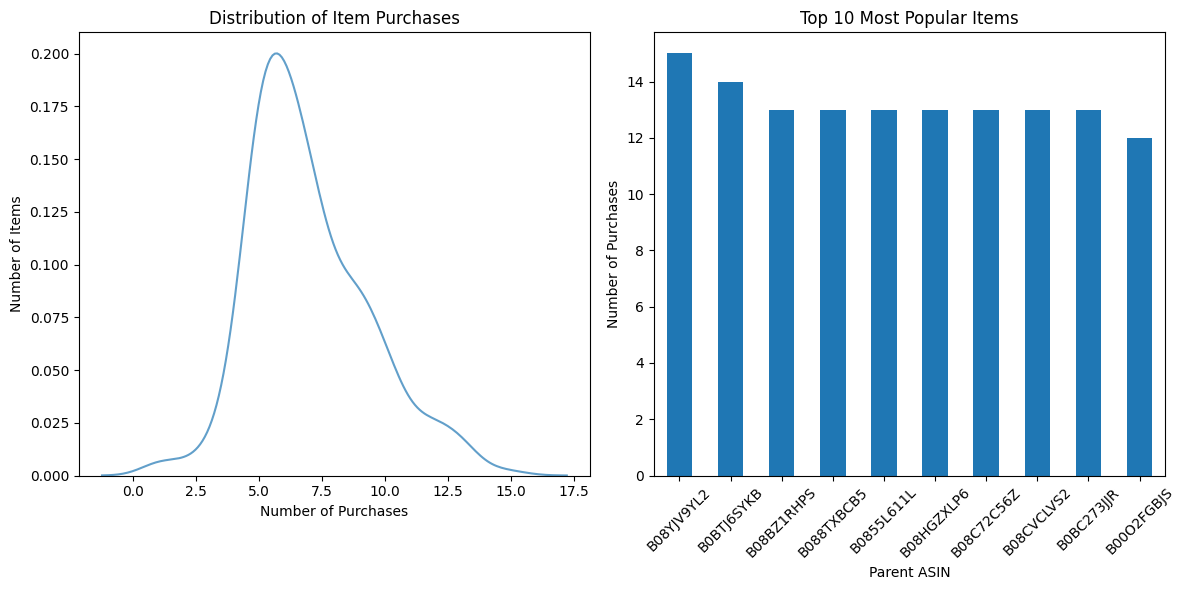


Item Purchase Distribution Statistics:
Mean purchases per item: 6.97
Median purchases per item: 6.00
Max purchases for an item: 15
Min purchases for an item: 1
Standard deviation: 2.36

User Statistics:
 Average purchases per user: 8.88
 Median purchases per user: 7.00
 Max purchases for a user: 62
 Min purchases for a user: 1
 Standard deviation: 6.82

Text Data Statistics:
Average tokens per item: 101.13
Max tokens for an item: 485
Min tokens for an item: 36


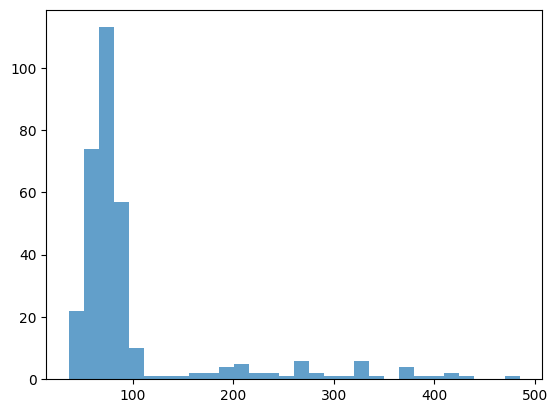

In [119]:
#Exploratory Data Analysis (EDA)
from matplotlib import pyplot as plt
import seaborn as sns
print(f"Number of unique items: {metadata_df.shape[0]}")
print(f"Number of unique users: {len(train_df['user_id'].unique())}")
print("Training set size: ", train_df.shape[0])
print("Training set unique items: ", train_df['parent_asin'].nunique())
print("Training set unique users: ", train_df['user_id'].nunique())
print("Test set size: ", test_df.shape[0])
print("Test set unique items: ", test_df['parent_asin'].nunique())
print("Test set unique users: ", test_df['user_id'].nunique())

# Distribution of item purchases (popularity)
item_purchase_counts = pd.concat([train_df['parent_asin'], test_df['parent_asin']]).value_counts()
top_items = item_purchase_counts.head(10)

# Plotting the distribution of item purchases
plt.figure(figsize=(12, 6))

# Plot histogram of item purchase counts
plt.subplot(1, 2, 1)
sns.kdeplot(item_purchase_counts, alpha=0.7)
plt.title('Distribution of Item Purchases')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Items')

# Plot top 10 most popular items
plt.subplot(1, 2, 2)
top_items.plot(kind='bar')
plt.title('Top 10 Most Popular Items')
plt.xlabel('Parent ASIN')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Basic statistics of purchase distribution
print("\nItem Purchase Distribution Statistics:")
print(f"Mean purchases per item: {item_purchase_counts.mean():.2f}")
print(f"Median purchases per item: {item_purchase_counts.median():.2f}")
print(f"Max purchases for an item: {item_purchase_counts.max()}")
print(f"Min purchases for an item: {item_purchase_counts.min()}")
print(f"Standard deviation: {item_purchase_counts.std():.2f}")

# Basic user statistics
print("\nUser Statistics:")
print(f" Average purchases per user: {train_df['user_id'].value_counts().mean():.2f}")
print(f" Median purchases per user: {train_df['user_id'].value_counts().median():.2f}")
print(f" Max purchases for a user: {train_df['user_id'].value_counts().max()}")
print(f" Min purchases for a user: {train_df['user_id'].value_counts().min()}")
print(f" Standard deviation: {train_df['user_id'].value_counts().std():.2f}")

# Check for text data statistics if available
if 'source_text' in metadata_df.columns:
    # Calculate token counts (approximation by word count)
    metadata_df['token_count'] = metadata_df['source_text'].str.split().str.len()
    
    print("\nText Data Statistics:")
    print(f"Average tokens per item: {metadata_df['token_count'].mean():.2f}")
    print(f"Max tokens for an item: {metadata_df['token_count'].max()}")
    print(f"Min tokens for an item: {metadata_df['token_count'].min()}")

plt.hist(metadata_df['token_count'], bins=30, alpha=0.7)
plt.show()

Notes: 

+ Small dataset with only few items and users. 
+ Test set is very small with 22 observations. Limits the expressiveness of the test results.
+ Products description are not very long with average of roughly 100 tokens. Could limit the performance of the clustering techniques in building informative topics and hierarchical taxonomies. Semantic representation of products could be very similar because of the few tokens. 
+ Distribution of item purchases is nearly normal distributed, not skewed. Implies that the model is forced to learn patterns in the data and not just predict the most popular items.
+ User on average buy 9 items. Could mean that there are user purchase prefferences or patterns which could be modeled by the taxonomie creation techniques.
+ Test set has 11 unique items of 22 observations. Good for testing, because accuracy will rely not soly on few products which might be overrepresented.


To observe the assumptions about user purchase patterns and the uniqueness of test obersavations we will explore them in more detail in the next section.

In [120]:
user_purchase_counts = train_df['user_id'].value_counts()
user_purchase_counts.sort_values(ascending=False).head(10)

user_id
AG73BVBKUOH22USSFJA5ZWL7AKXA      62
AEZP6Z2C5AVQDZAJECQYZWQRNG3Q      52
AEOK4TQIKGO23SJKZ6PW4FETNNDA_1    36
AHY2TURQPNIDXZGH2CMQLZ343YMQ      28
AF2BLE54TEMGZ546U763ZHZRXC4A      28
AGYVC7KVHP2AWM7BDCEYNHFA6F3Q      25
AEHWKRPNWNMOAJSMO2F6O7RFRTNA      24
AGFLDIUYV2PKF5Q7IEMULR52GW2Q      24
AH3BXW7KLIS2VAE56UXJS2NS7I5A      24
AEMP3A7IKW37CMWFXNKXWW6HGJHA_1    24
Name: count, dtype: int64

We explore the user purchase patterns of user `AEMP3A7IKW37CMWFXNKXWW6HGJHA_1`


In [121]:
user_purchases = train_df[train_df['user_id'] == 'AEMP3A7IKW37CMWFXNKXWW6HGJHA_1']

user_purchases_metadata = metadata_df[metadata_df['parent_asin'].isin(user_purchases['parent_asin'])]

for index, row in user_purchases_metadata.iterrows():
    print(row['parent_asin'], row['source_text'])
    print("--------------------------------")


B08JCX3DL7 Parent ASIN: B08JCX3DL7; Title: Pippa Of London Magic Star Eyeshadow Powder Pencil, Long Lasting, Blendable Eye Make Up Stick; Author: *; Description: *; Features: Features: 'THE FIRST EYESHADOW POWDER IN A PENCIL\xa0–\xa0 pressed\xa0under\xa0high pressure\xa0into\xa0an\xa0innovative\xa0eye pencil\xa0that goes on\xa0like a dream to give you intense\xa0velvety colour and highlighter that’s easy to blend and\xa0doesn’t smudge or crease', 'INTENSE COLOUR\xa0TO USE WET OR DRY\xa0–\xa0\xa0a\xa0world class formulation, expertly\xa0made\xa0with intense\xa0pigments for\xa0super wearable, vibrant, no fade\xa0colour\xa0that\xa0lasts\xa0all\xa0day', 'EASY TO SHARPEN –\xa0the pencil sharpens quickly and easily without clogging up your sharpener,\xa0to give you\xa0fresh eye shadow powder whenever you need it', 'CRUELTY FREE- All Pippa of London’s\xa0cosmetics are made\xa0to the highest standards of quality using the finest ingredients and are never, ever tested on anim', 'GENUINE\xa0PIPP

One patterns we see is that the users bought multiple items with focus on nails. For instance _Pine Gel Nail Polish Set_, _NAILGIL Poly Nail Gel_, _Poly Nail Gel Kit_ and _20pcs Nail Tips Clips_. Other possible prefferences are less obvious. The brands bought are divers. Additionally we couldnt regocnize trends like ingridients, features or others. 

test_items

In [122]:
test_items = test_df.drop_duplicates(subset=['parent_asin'])

test_items_metadata = metadata_df[metadata_df['parent_asin'].isin(test_items['parent_asin'])]

for index, row in test_items_metadata.iterrows():
    print(row['parent_asin'], row['source_text'])
    print("--------------------------------")


B08F79Z1Q5 Parent ASIN: B08F79Z1Q5; Title: MEACOLIA 6 Pack 8oz Water Mist Empty Spray Bottle for Hair,Plastic Spray Bottle for Cleaning Solutions,Refillable Container with Adjustable Head; Author: *; Description: *; Features: * - Details: Brand: MEACOLIA, Material: Plastic, Capacity: 8 Ounces, Package Dimensions: 10 x 9.13 x 4.25 inches; 9.59 Ounces, UPC: 193499864359; Store: Store: MEACOLIA; Categories: *; Price: Price: None;
--------------------------------
B086GST51S Parent ASIN: B086GST51S; Title: 3D Mink Eyelashes Natural Long Lashes 2 in 1 Self-adhesive Eyeliner Instead of Adhesive 5 Different Styles Pairs Kits Sets with Tweezers , NO NEED GLUE; Author: *; Description: *; Features: * - Details: Brand: PURELEOR, Material: Mink Fur, Item Form: Pair, Mounting Type: Eyelash Glue, Unit Count: 5.00 Count, Package Dimensions: 9 x 6 x 1 inches; 2.4 Ounces, UPC: 750810450143; Store: Store: PURELEOR; Categories: *; Price: Price: None;
--------------------------------
B07JGD2T2J Parent ASIN

Diverse product spectrum. Allows to see if taxonomies, which enhance complexity of Knowledge Graph relations are able to boost prediction performance.

## 2. Experiment

### 2.1 Baseline 

In [123]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
DATASET = DATASETS[1]

MODEL_TECHNIQUE = MODEL_TECHNIQUES[5].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)
os.makedirs(EXPERIMENT_DATA_PATH, exist_ok=True)

data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

# because the baseline kg only uses the user-item interactions, we need to create a kg with only the user-item interactions
prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)

kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg_without_taxonomy(train_df, test_df,EXPERIMENT_DATA_PATH)
kg_df.to_csv(EXPERIMENT_DATA_PATH+'/'+f'{MODEL_TECHNIQUE}_relations.csv')

# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
kg_df = kg_df[['head','relation','tail']]
kg_df.to_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')
baseline_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/baseline
Combined KG has 2259 unique triples.
Found 576 unique entities.
Found 1 unique relations.
Mapped 2237 train interactions.
Mapped 22 test interactions.
Mapped KG has 2259 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/baseline/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/baseline/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/baseline/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/baseline


In [124]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epochs', EPOCHS])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])

n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    baseline_density = nx.density(graph)
    print(f"Density of the graph: {baseline_density}")
    baseline_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {baseline_avg_degree}")
    baseline_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {baseline_max_degree}")
    baseline_depth = nx.average_shortest_path_length(graph)
    print(f"Average shortest path length of the graph: {baseline_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret, baseline_df_preds = test(model, user_dict, n_params)
        # save the predictions
        baseline_df_preds.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)

        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        baseline_metrics_table = PrettyTable()
        baseline_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            baseline_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            baseline_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            baseline_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            baseline_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        baseline_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        baseline_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        baseline_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        baseline_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        baseline_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(baseline_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Ignoring unrecognized arguments: ['--epochs', '100']
Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/baseline/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/baseline/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/baseline/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 252/252 [00:00<00:00, 1223338.67it/s]



Begin to load knowledge graph triples ...


100%|##########| 4518/4518 [00:00<00:00, 279302.92it/s]


End to build graph ... MultiDiGraph with 576 nodes and 4518 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0126  |
|     NDCG@20      |  0.0242  |
|   Precision@20   |  0.0139  |
|   Hit_Ratio@20   |  0.2222  |
|    Recall@40     |  0.0227  |
|     NDCG@40      |  0.0376  |
|   Precision@40   |  0.0125  |
|   Hit_Ratio@40   |  0.3889  |
|    Recall@60     |  0.0354  |
|     NDCG@60      |  0.

Python(28531) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Python(28532) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Python(28533) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forke

Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0126  |
|     NDCG@20      |  0.0242  |
|   Precision@20   |  0.0139  |
|   Hit_Ratio@20   |  0.2222  |
|    Recall@40     |  0.0227  |
|     NDCG@40      |  0.0376  |
|   Precision@40   |  0.0125  |
|   Hit_Ratio@40   |  0.3889  |
|    Recall@60     |  0.0354  |
|     NDCG@60      |  0.

Python(28544) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Python(28545) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Python(28546) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forke

Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0126  |
|     NDCG@20      |  0.0242  |
|   Precision@20   |  0.0139  |
|   Hit_Ratio@20   |  0.2222  |
|    Recall@40     |  0.0227  |
|     NDCG@40      |  0.0376  |
|   Precision@40   |  0.0125  |
|   Hit_Ratio@40   |  0.3889  |
|    Recall@60     |  0.0354  |
|     NDCG@60      |  0.

### 2.2 Hierarchical Topic Modeling
#### 2.2.1 all-MiniLM-L6-v2

In [76]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASET = DATASETS[1]

MODEL_TECHNIQUE = MODEL_TECHNIQUES[0].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')
# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
all_mini_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')

prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg(all_mini_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/all-MiniLM-L6-v2
Combined KG has 2599 unique triples.
Found 592 unique entities.
Found 3 unique relations.
Mapped 2237 train interactions.
Mapped 22 test interactions.
Mapped KG has 2599 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/all-MiniLM-L6-v2/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/all-MiniLM-L6-v2/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/all-MiniLM-L6-v2/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/all-MiniLM-L6-v2


In [79]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epochs', EPOCHS])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])

n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    all_mini_density = nx.density(graph)
    print(f"Density of the graph: {all_mini_density}")
    all_mini_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {all_mini_avg_degree}")
    all_mini_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {all_mini_max_degree}")
    all_mini_depth = nx.average_shortest_path_length(graph)
    print(f"Average shortest path length of the graph: {all_mini_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret, all_mini_preds = test(model, user_dict, n_params)
        # save predictions
        all_mini_preds.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)

        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        all_mini_metrics_table = PrettyTable()
        all_mini_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            all_mini_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            all_mini_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            all_mini_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            all_mini_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        all_mini_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        all_mini_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        all_mini_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        all_mini_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        all_mini_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(all_mini_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Ignoring unrecognized arguments: ['--epochs', '100']
Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/all-MiniLM-L6-v2/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/all-MiniLM-L6-v2/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/all-MiniLM-L6-v2/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 252/252 [00:00<00:00, 1339625.61it/s]



Begin to load knowledge graph triples ...


100%|##########| 5198/5198 [00:00<00:00, 732396.94it/s]


End to build graph ... MultiDiGraph with 592 nodes and 5198 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0000  |
|     NDCG@20      |  0.0000  |
|   Precision@20   |  0.0000  |
|   Hit_Ratio@20   |  0.0000  |
|    Recall@40     |  0.0000  |
|     NDCG@40      |  0.0000  |
|   Precision@40   |  0.0000  |
|   Hit_Ratio@40   |  0.0000  |
|    Recall@60     |  0.0111  |
|     NDCG@60      |  0.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0000  |
|     NDCG@20      |  0.0000  |
|   Precision@20   |  0.0000  |
|   Hit_Ratio@20   |  0.0000  |
|    Recall@40     |  0.0000  |
|     NDCG@40      |  0.0000  |
|   Precision@40   |  0.0000  |
|   Hit_Ratio@40   |  0.0000  |
|    Recall@60     |  0.0111  |
|     NDCG@60      |  0.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Ignoring unrecognized arguments: ['--epochs', '100']
Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0000  |
|     NDCG@20      |  0.0000  |
|   Precision@20   |  0.0000  |
|   Hit_Ratio@20   |  0.0000  |
|    Recall@40     |  0.0000  |
|     NDCG@40      |  0.0000  |
|   Precision@40   |  0.0000  |
|   Hit_Ratio@40   |  0.0000  |
|    Recall@60     |  0.0111  |
|     NDCG@60      |  0.

#### 2.1.2 intfloat/multilingual-e5-large-instruct

build triplets from hierarchies for selected techniques

In [80]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
MODEL_TECHNIQUE = MODEL_TECHNIQUES[1].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [81]:
# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
e5_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')
prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg(e5_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/intfloat_multilingual-e5-large-instruct
Combined KG has 2517 unique triples.
Found 592 unique entities.
Found 3 unique relations.
Mapped 2237 train interactions.
Mapped 22 test interactions.
Mapped KG has 2517 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/intfloat_multilingual-e5-large-instruct/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/intfloat_multilingual-e5-large-instruct/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/intfloat_multilingual-e5-large-instruct/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty

set dataset configuration in parser

In [82]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])

n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    e5_density = nx.density(graph)
    print(f"Density of the graph: {e5_density}")
    e5_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {e5_avg_degree}")
    e5_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {e5_max_degree}")
    e5_depth = nx.average_shortest_path_length(graph)
    print(f"Average shortest path length of the graph: {e5_depth}")

    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret,e5_preds = test(model, user_dict, n_params)
        # save predictions
        e5_preds.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        e5_metrics_table = PrettyTable()
        e5_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            e5_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            e5_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            e5_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            e5_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        e5_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        e5_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        e5_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        e5_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        e5_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(e5_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/intfloat_multilingual-e5-large-instruct/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/intfloat_multilingual-e5-large-instruct/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/intfloat_multilingual-e5-large-instruct/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 252/252 [00:00<00:00, 1490782.24it/s]



Begin to load knowledge graph triples ...


100%|##########| 5034/5034 [00:00<00:00, 694749.31it/s]


End to build graph ... MultiDiGraph with 592 nodes and 5034 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0243  |
|     NDCG@20      |  0.0613  |
|   Precision@20   |  0.0194  |
|   Hit_Ratio@20   |  0.3889  |
|    Recall@40     |  0.0347  |
|     NDCG@40      |  0.0709  |
|   Precision@40   |  0.0139  |
|   Hit_Ratio@40   |  0.5000  |
|    Recall@60     |  0.0590  |
|     NDCG@60      |  0.0918  |
|   Precision@60   |  0.0157  |
|   Hit_Ratio@60   |  0.6667  |
|    Recall@80     |  0.0694  |
|     NDCG@80      |  0.0998  |
|   Precision@80   |  0.0139  |
|   Hit_Ratio@80   |  0.6667  |
|    Recall@100    |  0.0764  |
|     NDCG@100     |  0.1050  |
|  Precision@100   |  0.0122  |
|  Hit_Ratio@100   |  0.7778  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.05   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0243  |
|     NDCG@20      |  0.0613  |
|   Precision@20   |  0.0194  |
|   Hit_Ratio@20   |  0.3889  |
|    Recall@40     |  0.0347  |
|     NDCG@40      |  0.0709  |
|   Precision@40   |  0.0139  |
|   Hit_Ratio@40   |  0.5000  |
|    Recall@60     |  0.0590  |
|     NDCG@60      |  0.0918  |
|   Precision@60   |  0.0157  |
|   Hit_Ratio@60   |  0.6667  |
|    Recall@80     |  0.0694  |
|     NDCG@80      |  0.0998  |
|   Precision@80   |  0.0139  |
|   Hit_Ratio@80   |  0.6667  |
|    Recall@100    |  0.0764  |
|     NDCG@100     |  0.1050  |
|  Precision@100   |  0.0122  |
|  Hit_Ratio@100   |  0.7778  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0243  |
|     NDCG@20      |  0.0613  |
|   Precision@20   |  0.0194  |
|   Hit_Ratio@20   |  0.3889  |
|    Recall@40     |  0.0347  |
|     NDCG@40      |  0.0709  |
|   Precision@40   |  0.0139  |
|   Hit_Ratio@40   |  0.5000  |
|    Recall@60     |  0.0590  |
|     NDCG@60      |  0.0918  |
|   Precision@60   |  0.0157  |
|   Hit_Ratio@60   |  0.6667  |
|    Recall@80     |  0.0694  |
|     NDCG@80      |  0.0998  |
|   Precision@80   |  0.0139  |
|   Hit_Ratio@80   |  0.6667  |
|    Recall@100    |  0.0764  |
|     NDCG@100     |  0.1050  |
|  Precision@100   |  0.0122  |
|  Hit_Ratio@100   |  0.7778  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

#### 2.2.3 Alibaba-NLP/gte-Qwen2-1.5B-instruct

In [83]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
MODEL_TECHNIQUE = MODEL_TECHNIQUES[2].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [84]:
# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
qwen2_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')
prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg(qwen2_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/Alibaba-NLP_gte-Qwen2-1.5B-instruct
Combined KG has 2597 unique triples.
Found 590 unique entities.
Found 3 unique relations.
Mapped 2237 train interactions.
Mapped 22 test interactions.
Mapped KG has 2597 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/Alibaba-NLP_gte-Qwen2-1.5B-instruct/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/Alibaba-NLP_gte-Qwen2-1.5B-instruct/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/Alibaba-NLP_gte-Qwen2-1.5B-instruct/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/Alibaba-NLP_gte

In [85]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list
    
    qwen2_density = nx.density(graph)
    print(f"Density of the graph: {qwen2_density}")
    qwen2_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {qwen2_avg_degree}")
    qwen2_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {qwen2_max_degree}")

    qwen2_depth = nx.average_shortest_path_length(graph)
    print(f"Average shortest path length of the graph: {qwen2_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret,qwen2_predicitons = test(model, user_dict, n_params)
        # save predictions
        qwen2_predicitons.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        qwen2_metrics_table = PrettyTable()
        qwen2_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            qwen2_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            qwen2_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            qwen2_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            qwen2_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        qwen2_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        qwen2_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        qwen2_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        qwen2_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        qwen2_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(qwen2_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/Alibaba-NLP_gte-Qwen2-1.5B-instruct/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/Alibaba-NLP_gte-Qwen2-1.5B-instruct/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/Alibaba-NLP_gte-Qwen2-1.5B-instruct/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 252/252 [00:00<00:00, 1376256.00it/s]



Begin to load knowledge graph triples ...


100%|##########| 5194/5194 [00:00<00:00, 682879.29it/s]


End to build graph ... MultiDiGraph with 590 nodes and 5194 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0163  |
|     NDCG@20      |  0.0357  |
|   Precision@20   |  0.0139  |
|   Hit_Ratio@20   |  0.2778  |
|    Recall@40     |  0.0294  |
|     NDCG@40      |  0.0489  |
|   Precision@40   |  0.0125  |
|   Hit_Ratio@40   |  0.5000  |
|    Recall@60     |  0.0359  |
|     NDCG@60      |  0.0548  |
|   Precision@60   |  0.0102  |
|   Hit_Ratio@60   |  0.6111  |
|    Recall@80     |  0.0425  |
|     NDCG@80      |  0.0603  |
|   Precision@80   |  0.0090  |
|   Hit_Ratio@80   |  0.6667  |
|    Recall@100    |  0.0490  |
|     NDCG@100     |  0.0655  |
|  Precision@100   |  0.0083  |
|  Hit_Ratio@100   |  0.7222  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0163  |
|     NDCG@20      |  0.0357  |
|   Precision@20   |  0.0139  |
|   Hit_Ratio@20   |  0.2778  |
|    Recall@40     |  0.0294  |
|     NDCG@40      |  0.0489  |
|   Precision@40   |  0.0125  |
|   Hit_Ratio@40   |  0.5000  |
|    Recall@60     |  0.0359  |
|     NDCG@60      |  0.0548  |
|   Precision@60   |  0.0102  |
|   Hit_Ratio@60   |  0.6111  |
|    Recall@80     |  0.0425  |
|     NDCG@80      |  0.0603  |
|   Precision@80   |  0.0090  |
|   Hit_Ratio@80   |  0.6667  |
|    Recall@100    |  0.0490  |
|     NDCG@100     |  0.0655  |
|  Precision@100   |  0.0083  |
|  Hit_Ratio@100   |  0.7222  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0163  |
|     NDCG@20      |  0.0357  |
|   Precision@20   |  0.0139  |
|   Hit_Ratio@20   |  0.2778  |
|    Recall@40     |  0.0294  |
|     NDCG@40      |  0.0489  |
|   Precision@40   |  0.0125  |
|   Hit_Ratio@40   |  0.5000  |
|    Recall@60     |  0.0359  |
|     NDCG@60      |  0.0548  |
|   Precision@60   |  0.0102  |
|   Hit_Ratio@60   |  0.6111  |
|    Recall@80     |  0.0425  |
|     NDCG@80      |  0.0603  |
|   Precision@80   |  0.0090  |
|   Hit_Ratio@80   |  0.6667  |
|    Recall@100    |  0.0490  |
|     NDCG@100     |  0.0655  |
|  Precision@100   |  0.0083  |
|  Hit_Ratio@100   |  0.7222  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

regex similarity between taxnonmy of embedding models

In [86]:
def collect_unique_values(df):
    unique_values = []
    for column in ['head', 'tail']:  # Only consider head and tail columns where entities are stored
        if column in df.columns:
            # Convert to string and filter out nans
            values = df[column].dropna().astype(str).unique().tolist()
            unique_values.extend(values)
    
    # Filter parent ASINs (product IDs that start with 'B')
    unique_values = [value for value in unique_values if isinstance(value, str) and not value.startswith('B')]
    
    # Only unique values
    unique_values = list(set(unique_values))
    return unique_values

# Now use the function
def levenshtein_distance(df1, df2):
    """Calculate normalized Levenshtein distance between two sets of taxonomy terms"""
    
    # Get unique values from each DataFrame (excluding product IDs)
    unique_values_df1 = collect_unique_values(df1)
    unique_values_df2 = collect_unique_values(df2)
    
    
    # Calculate Levenshtein ratio for each pair of terms
    total_similarity = 0
    valid_comparisons = 0
    
    for term1 in unique_values_df1:
        for term2 in unique_values_df2:
            # Skip if either term is not a valid string
            if not isinstance(term1, str) or not isinstance(term2, str):
                continue
                
            lev_ratio = Levenshtein.ratio(term1.lower(), term2.lower())
            total_similarity += lev_ratio
            valid_comparisons += 1
    
    # Avoid division by zero
    if valid_comparisons == 0:
        return 0
        
    avg_lev_ratio = total_similarity / valid_comparisons
    return avg_lev_ratio

e5_qwen2_lev_ratio = levenshtein_distance(e5_triplet_df, qwen2_triplet_df)
e5_mini_lev_ratio = levenshtein_distance(e5_triplet_df, all_mini_triplet_df)
qwen2_mini_lev_ratio = levenshtein_distance(qwen2_triplet_df, all_mini_triplet_df)

print(f"Levenshtein distance between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: {e5_qwen2_lev_ratio}") 
print(f"Levenshtein distance between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: {e5_mini_lev_ratio}")    
print(f"Levenshtein distance between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: {qwen2_mini_lev_ratio}")

Levenshtein distance between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: 0.36137060757000217
Levenshtein distance between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: 0.37738304012078433
Levenshtein distance between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: 0.35584056998320873


In [87]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Fix the cosine_similarity function to handle matrix inputs correctly
def cosine_similarity_matrices(matrix1, matrix2):
    # Transpose the second matrix to align dimensions for dot product
    matrix2_transposed = matrix2.T
    # Calculate dot product between matrices
    dot_product = np.dot(matrix1, matrix2_transposed)
    
    # Calculate norms for each row in both matrices
    norm_matrix1 = np.linalg.norm(matrix1, axis=1, keepdims=True)
    norm_matrix2 = np.linalg.norm(matrix2, axis=1, keepdims=True)
    
    # Calculate cosine similarity
    cosine_sim = dot_product / (np.dot(norm_matrix1, norm_matrix2.T))
    
    return cosine_sim

# Update the calc_cosine_similarity function to use the correct similarity function
def calc_cosine_similarity_fixed(df1, df2, embedding_model):
    def collect_unique_values(df):
        """Collect unique non-ASIN values from head and tail columns."""
        unique_values = []
        for column in ['head', 'tail']:
            if column in df.columns:
                # Drop NaN values, convert to strings, then get unique values
                values = df[column].dropna().astype(str).unique().tolist()
                # Filter out ASINs (product IDs starting with 'B')
                values = [val for val in values if not val.startswith('B')]
                unique_values.extend(values)
        
        # Remove duplicates
        unique_values = list(set(unique_values))
        return unique_values
    
    # Get unique values from each dataframe
    unique_values_df1 = collect_unique_values(df1)
    unique_values_df2 = collect_unique_values(df2)
    
    # Print count of terms being compared (for debugging)
    print(f"Comparing {len(unique_values_df1)} terms from df1 with {len(unique_values_df2)} terms from df2")
    
    # Skip if either list is empty
    if not unique_values_df1 or not unique_values_df2:
        print("Warning: One or both term lists are empty, returning 0")
        return 0

    # Embed unique values
    unique_values_df1_embed = embedding_model.encode(unique_values_df1)
    unique_values_df2_embed = embedding_model.encode(unique_values_df2)

    # Use the fixed cosine similarity function for matrices
    cosine_similarity_matrix = cosine_similarity_matrices(unique_values_df1_embed, unique_values_df2_embed).mean()

    return cosine_similarity_matrix

# Use the fixed function
print(f"Cosine similarity between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: {calc_cosine_similarity_fixed(e5_triplet_df, all_mini_triplet_df, embedding_model)}")
print(f"Cosine similarity between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: {calc_cosine_similarity_fixed(qwen2_triplet_df, all_mini_triplet_df, embedding_model)}")
print(f"Cosine similarity between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: {calc_cosine_similarity_fixed(e5_triplet_df, qwen2_triplet_df, embedding_model)}")

Comparing 15 terms from df1 with 15 terms from df2
Cosine similarity between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: 0.47142449021339417
Comparing 13 terms from df1 with 15 terms from df2
Cosine similarity between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: 0.3843494951725006
Comparing 15 terms from df1 with 13 terms from df2
Cosine similarity between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: 0.39667922258377075


To measure similarity between the different constructed topics of the different embedding models cosine similarity seems to be the better similarity measure. As displayed in the above the embedding models in BERTTopic generate lexical very different topics with the same meaning. For instance the topic `nails_nail_gel_manicure_acrylic` of the multi-lingual-e5-large-instruct and `gel_manicure_acrylic_nails_glitter` of the all-MiniLM-L6-v2 are  different lexical but have the same meaning. The levenstein ratio for all scenarios is 0 and doesnt capture lexical no similarites between topics. Meanwhile the cosine similarities are between 0.39 to 0.54. 


![BERTopic Algorithm](https://maartengr.github.io/BERTopic/algorithm/default.svg)


Looking at the BERTTopic algorithm gives an explanation for this. 
To create topic represantation BERTTopic uses after clustering Bag-of-Words (CountVectorizer). It counts how often words appears in a given cluster. Further it uses a TF-IDF transformation to weight the words to focus on specific words in a cluster. In this case the created cluster seems to be similar, but not the same. Therefore curtent words may apear less in the cluster and wont be used in the TF-IDF transformation. On the other hand the intersection of the topics provide semantically similar topics which can be seen in the cosine similarity.

### 2.3 Hearst-Patterns Named-Entity-Recognition (Rebel-large)

In [88]:

MODEL_TECHNIQUE = MODEL_TECHNIQUES[4].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [89]:
# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
rebel_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')
len_before = len(rebel_triplet_df)
# filter out relation where one column is empty
rebel_triplet_df = rebel_triplet_df[rebel_triplet_df['head'].notna() & rebel_triplet_df['tail'].notna()]
len_after = len(rebel_triplet_df)
filtered_out = len_before - len_after
print(f"Filtered out {filtered_out} relations where one column is empty")
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')
prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg(rebel_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Filtered out 284 relations where one column is empty
Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/ner
Combined KG has 2554 unique triples.
Found 769 unique entities.
Found 19 unique relations.
Mapped 2237 train interactions.
Mapped 22 test interactions.
Mapped KG has 2554 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/ner/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/ner/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/ner/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/ner


In [90]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    rebel_density = nx.density(graph)
    print(f"Density of the graph: {rebel_density}")
    rebel_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {rebel_avg_degree}")
    rebel_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {rebel_max_degree}")
    rebel_depth = nx.average_shortest_path_length(graph)
    print(f"Average shortest path length of the graph: {rebel_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret,rebel_predictions = test(model, user_dict, n_params)
        # save predictions
        rebel_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        rebel_metrics_table = PrettyTable()
        rebel_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            rebel_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            rebel_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            rebel_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            rebel_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        rebel_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        rebel_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        rebel_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        rebel_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        rebel_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(rebel_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/ner/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/ner/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/ner/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 252/252 [00:00<00:00, 1285845.02it/s]



Begin to load knowledge graph triples ...


100%|##########| 5108/5108 [00:00<00:00, 713294.21it/s]


End to build graph ... MultiDiGraph with 769 nodes and 5108 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0154  |
|     NDCG@20      |  0.0213  |
|   Precision@20   |  0.0139  |
|   Hit_Ratio@20   |  0.2222  |
|    Recall@40     |  0.0247  |
|     NDCG@40      |  0.0312  |
|   Precision@40   |  0.0111  |
|   Hit_Ratio@40   |  0.3333  |
|    Recall@60     |  0.0401  |
|     NDCG@60      |  0.0460  |
|   Precision@60   |  0.0120  |
|   Hit_Ratio@60   |  0.5556  |
|    Recall@80     |  0.0494  |
|     NDCG@80      |  0.0541  |
|   Precision@80   |  0.0111  |
|   Hit_Ratio@80   |  0.6111  |
|    Recall@100    |  0.0679  |
|     NDCG@100     |  0.0696  |
|  Precision@100   |  0.0122  |
|  Hit_Ratio@100   |  0.6667  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0154  |
|     NDCG@20      |  0.0213  |
|   Precision@20   |  0.0139  |
|   Hit_Ratio@20   |  0.2222  |
|    Recall@40     |  0.0247  |
|     NDCG@40      |  0.0312  |
|   Precision@40   |  0.0111  |
|   Hit_Ratio@40   |  0.3333  |
|    Recall@60     |  0.0401  |
|     NDCG@60      |  0.0460  |
|   Precision@60   |  0.0120  |
|   Hit_Ratio@60   |  0.5556  |
|    Recall@80     |  0.0494  |
|     NDCG@80      |  0.0541  |
|   Precision@80   |  0.0111  |
|   Hit_Ratio@80   |  0.6111  |
|    Recall@100    |  0.0679  |
|     NDCG@100     |  0.0696  |
|  Precision@100   |  0.0122  |
|  Hit_Ratio@100   |  0.6667  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0154  |
|     NDCG@20      |  0.0213  |
|   Precision@20   |  0.0139  |
|   Hit_Ratio@20   |  0.2222  |
|    Recall@40     |  0.0247  |
|     NDCG@40      |  0.0312  |
|   Precision@40   |  0.0111  |
|   Hit_Ratio@40   |  0.3333  |
|    Recall@60     |  0.0401  |
|     NDCG@60      |  0.0460  |
|   Precision@60   |  0.0120  |
|   Hit_Ratio@60   |  0.5556  |
|    Recall@80     |  0.0494  |
|     NDCG@80      |  0.0541  |
|   Precision@80   |  0.0111  |
|   Hit_Ratio@80   |  0.6111  |
|    Recall@100    |  0.0679  |
|     NDCG@100     |  0.0696  |
|  Precision@100   |  0.0122  |
|  Hit_Ratio@100   |  0.6667  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

### 2.4 LLM-Col-Hierarchy-Tax (Gemma 3)


In [91]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here

MODEL_TECHNIQUE = MODEL_TECHNIQUES[3].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [92]:
# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy-triples.csv')
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')
prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg(gemma_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/gemma3
Combined KG has 4708 unique triples.
Found 678 unique entities.
Found 3 unique relations.
Mapped 2237 train interactions.
Mapped 22 test interactions.
Mapped KG has 2449 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/gemma3/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/gemma3/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/gemma3/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/gemma3


In [93]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    gemma_density = nx.density(graph)
    print(f"Density of the graph: {gemma_density}")
    gemma_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {gemma_avg_degree}")
    gemma_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {gemma_max_degree}")
    gemma_avg_shortest_path_length = nx.average_shortest_path_length(graph)
    print(f"Average shortest path length of the graph: {gemma_avg_shortest_path_length}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret,gemma_predictions = test(model, user_dict, n_params)
        # save predictions
        gemma_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        gemma_metrics_table = PrettyTable()
        gemma_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            gemma_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            gemma_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            gemma_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            gemma_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        gemma_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        gemma_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        gemma_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        gemma_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        gemma_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(gemma_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/gemma3/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/gemma3/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-All_Beauty/gemma3/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 252/252 [00:00<00:00, 1067641.02it/s]



Begin to load knowledge graph triples ...


100%|##########| 4898/4898 [00:00<00:00, 771565.42it/s]


End to build graph ... MultiDiGraph with 399 nodes and 4898 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0175  |
|     NDCG@20      |  0.0646  |
|   Precision@20   |  0.0167  |
|   Hit_Ratio@20   |  0.2222  |
|    Recall@40     |  0.0322  |
|     NDCG@40      |  0.0812  |
|   Precision@40   |  0.0153  |
|   Hit_Ratio@40   |  0.5000  |
|    Recall@60     |  0.0351  |
|     NDCG@60      |  0.0842  |
|   Precision@60   |  0.0111  |
|   Hit_Ratio@60   |  0.5556  |
|    Recall@80     |  0.0585  |
|     NDCG@80      |  0.1060  |
|   Precision@80   |  0.0139  |
|   Hit_Ratio@80   |  0.7222  |
|    Recall@100    |  0.0702  |
|     NDCG@100     |  0.1163  |
|  Precision@100   |  0.0133  |
|  Hit_Ratio@100   |  0.7222  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0175  |
|     NDCG@20      |  0.0646  |
|   Precision@20   |  0.0167  |
|   Hit_Ratio@20   |  0.2222  |
|    Recall@40     |  0.0322  |
|     NDCG@40      |  0.0812  |
|   Precision@40   |  0.0153  |
|   Hit_Ratio@40   |  0.5000  |
|    Recall@60     |  0.0351  |
|     NDCG@60      |  0.0842  |
|   Precision@60   |  0.0111  |
|   Hit_Ratio@60   |  0.5556  |
|    Recall@80     |  0.0585  |
|     NDCG@80      |  0.1060  |
|   Precision@80   |  0.0139  |
|   Hit_Ratio@80   |  0.7222  |
|    Recall@100    |  0.0702  |
|     NDCG@100     |  0.1163  |
|  Precision@100   |  0.0133  |
|  Hit_Ratio@100   |  0.7222  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Saved predictions to all_predictions.csv

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0175  |
|     NDCG@20      |  0.0646  |
|   Precision@20   |  0.0167  |
|   Hit_Ratio@20   |  0.2222  |
|    Recall@40     |  0.0322  |
|     NDCG@40      |  0.0812  |
|   Precision@40   |  0.0153  |
|   Hit_Ratio@40   |  0.5000  |
|    Recall@60     |  0.0351  |
|     NDCG@60      |  0.0842  |
|   Precision@60   |  0.0111  |
|   Hit_Ratio@60   |  0.5556  |
|    Recall@80     |  0.0585  |
|     NDCG@80      |  0.1060  |
|   Precision@80   |  0.0139  |
|   Hit_Ratio@80   |  0.7222  |
|    Recall@100    |  0.0702  |
|     NDCG@100     |  0.1163  |
|  Precision@100   |  0.0133  |
|  Hit_Ratio@100   |  0.7222  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.00   |
| Test Time (min)  |   0.04   |
|    Outer Loss    | 0.000000 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
----------

## 3. Results

+ Get from all techniques the key accuracy metrics
+ calculate for the LLM-Col-Hierarchy-Tax method for every metric the delta to the best /second best method



Comparison of Different Taxonomy Methods:
+--------------------------------------------+-----------+--------------+---------+--------------+
|                   Method                   | Recall@20 | Precision@20 | NDCG@20 | Hit_Ratio@20 |
+--------------------------------------------+-----------+--------------+---------+--------------+
|                  Baseline                  |   0.0231  |    0.0139    |  0.0242 |    0.2222    |
|    Hierarchical-Topic-e5-large-instruct    |   0.0243  |    0.0194    |  0.0613 |    0.3889    |
|      Hierarchical-Topic-MiniLM-L6-v2       |   0.0000  |    0.0000    |  0.0000 |    0.0000    |
| Hierarchical-Topic-gte-Qwen2-1.5B-instruct |   0.0163  |    0.0139    |  0.0357 |    0.2778    |
|      Hearst-Patterns NER-Rebel-large       |   0.0154  |    0.0139    |  0.0213 |    0.2222    |
|           LLM-Col-Hierarchy-Tax            |   0.0175  |    0.0167    |  0.0646 |    0.2222    |
|      Delta LLM-Col-Hierarchy-Tax (%)       |  -27.9835 |   -13.91

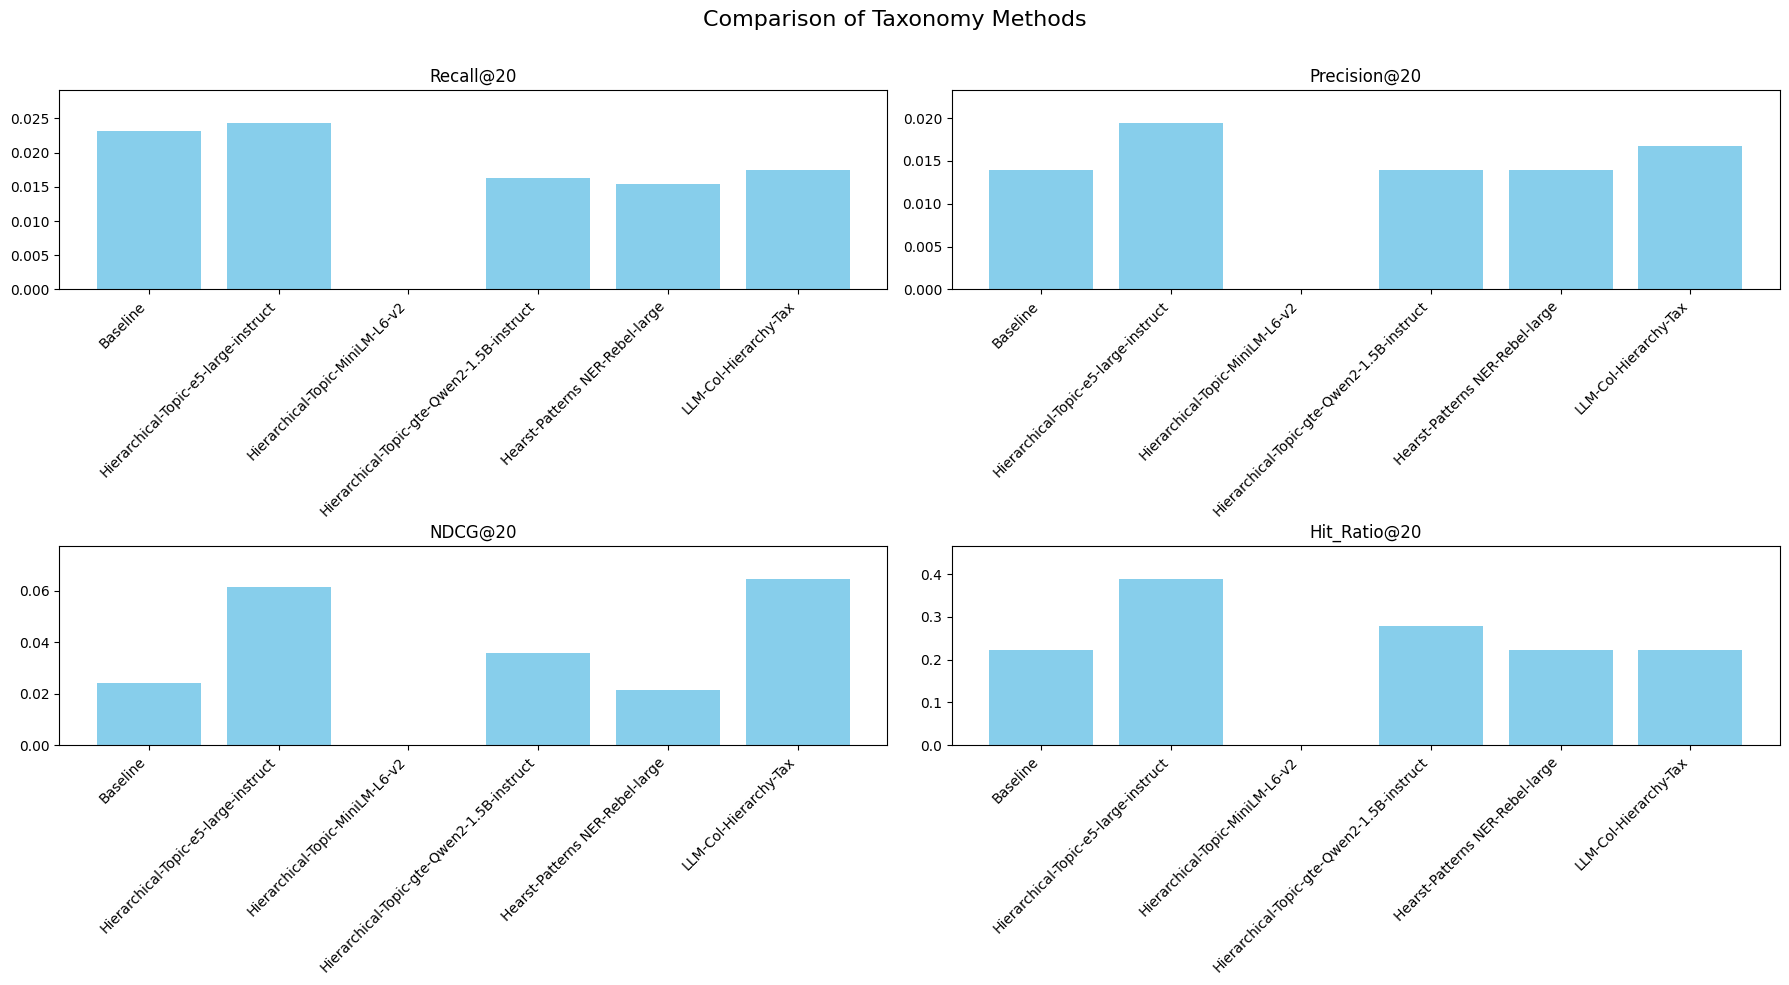

In [94]:
# Create a function to safely extract metrics from tables
def safe_extract_metrics(metrics_df, method_name):
    metrics = {}
    metrics['Method'] = method_name
    
    # Check if metrics_df is a PrettyTable
    if hasattr(metrics_df, 'get_string'):
        # Extract data from PrettyTable
        for row in metrics_df._rows:
            if row[0] == 'Recall@20':
                metrics['Recall@20'] = float(row[1])
            elif row[0] == 'Precision@20':
                metrics['Precision@20'] = float(row[1])
            elif row[0] == 'NDCG@20':
                metrics['NDCG@20'] = float(row[1])
            elif row[0] == 'Hit_Ratio@20':
                metrics['Hit_Ratio@20'] = float(row[1])
            elif row[0] == 'AUC':
                metrics['AUC'] = float(row[1])
    else:
        # Assume it's a DataFrame
        try:
            metrics['Recall@20'] = metrics_df.loc[metrics_df.index == 'Recall@20', 'Value'].iloc[0]
            metrics['Precision@20'] = metrics_df.loc[metrics_df.index == 'Precision@20', 'Value'].iloc[0]
            metrics['NDCG@20'] = metrics_df.loc[metrics_df.index == 'NDCG@20', 'Value'].iloc[0]
            metrics['Hit_Ratio@20'] = metrics_df.loc[metrics_df.index == 'Hit_Ratio@20', 'Value'].iloc[0]
            metrics['AUC'] = metrics_df.loc[metrics_df.index == 'AUC', 'Value'].iloc[0]
        except:
            # Default values if metrics are missing
            metrics['Recall@20'] = 0.0
            metrics['Precision@20'] = 0.0
            metrics['NDCG@20'] = 0.0
            metrics['Hit_Ratio@20'] = 0.0
            metrics['AUC'] = 0.0
    
    return metrics

# Use the safe extraction function instead
baseline_key_metrics = safe_extract_metrics(baseline_metrics_table, "Baseline")
e5_key_metrics = safe_extract_metrics(e5_metrics_table, "Hierarchical-Topic-e5-large-instruct")
all_mini_key_metrics = safe_extract_metrics(all_mini_metrics_table, "Hierarchical-Topic-MiniLM-L6-v2")
qwen2_key_metrics = safe_extract_metrics(qwen2_metrics_table, "Hierarchical-Topic-gte-Qwen2-1.5B-instruct")
rebel_key_metrics = safe_extract_metrics(rebel_metrics_table, "Hearst-Patterns NER-Rebel-large")
gemma_key_metrics = safe_extract_metrics(gemma_metrics_table, "LLM-Col-Hierarchy-Tax")

results_list = [baseline_key_metrics, e5_key_metrics, all_mini_key_metrics, qwen2_key_metrics, rebel_key_metrics, gemma_key_metrics]


# Find the best and second best values for each metric
metrics_to_compare = ['Recall@20', 'Precision@20', 'NDCG@20', 'Hit_Ratio@20']
best_values = {}
second_best_values = {}

for metric in metrics_to_compare:
    # Extract values for this metric from all methods
    values = [result[metric] for result in results_list]
    # Sort values in descending order
    sorted_values = sorted(values, reverse=True)
    
    # Store best and second best values
    if len(sorted_values) >= 1:
        best_values[metric] = sorted_values[0]
    if len(sorted_values) >= 2:
        second_best_values[metric] = sorted_values[1]

# Calculate delta for Gemma3 compared to baseline
gemma_deltas = {}

for metric in metrics_to_compare:
    gemma_value = gemma_key_metrics[metric]
    
    # Delta to best
    if metric in best_values:
        if gemma_value == best_values[metric]:
            # If Gemma is the best, compare to second best
            if metric in second_best_values:
                delta = gemma_value - second_best_values[metric]
                gemma_deltas[f"{metric}"] = delta
                gemma_deltas[f"{metric}"] = (delta / second_best_values[metric]) * 100 if second_best_values[metric] != 0 else float('inf')
        else:
            # If Gemma is not the best, compare to best
            delta = gemma_value - best_values[metric]
            gemma_deltas[f"{metric}"] = (delta / best_values[metric]) * 100 if best_values[metric] != 0 else float('inf')
# add to results_list
results_list[5]['LLM-Col-Hierarchy-Tax_Delta'] = gemma_deltas

# Create a pretty table to display the results
from prettytable import PrettyTable

acc_comparison_table = PrettyTable()
acc_comparison_table.field_names = ["Method", "Recall@20", "Precision@20", "NDCG@20", "Hit_Ratio@20"]

# Add rows to the table
for result in results_list:
    acc_comparison_table.add_row([
        result['Method'],
        f"{result['Recall@20']:.4f}",
        f"{result['Precision@20']:.4f}",
        f"{result['NDCG@20']:.4f}",
        f"{result['Hit_Ratio@20']:.4f}",
    ])

# add gemma3_delta to the table
acc_comparison_table.add_row([
    "Delta LLM-Col-Hierarchy-Tax (%)",
    f"{gemma_deltas['Recall@20']:.4f}",
    f"{gemma_deltas['Precision@20']:.4f}",
    f"{gemma_deltas['NDCG@20']:.4f}",
    f"{gemma_deltas['Hit_Ratio@20']:.4f}",
])

# Display the comparison table
print("Comparison of Different Taxonomy Methods:")
print(acc_comparison_table)

# Optionally, create a bar chart to visualize the comparison
import matplotlib.pyplot as plt
import numpy as np

# Check if we have results to plot
if results_list:
    # Extract method names and metrics
    method_names = [result['Method'] for result in results_list]
    recall_values = [result['Recall@20'] for result in results_list]
    precision_values = [result['Precision@20'] for result in results_list]
    ndcg_values = [result['NDCG@20'] for result in results_list]
    hr_values = [result['Hit_Ratio@20'] for result in results_list]
    
    # Set up the figure
    fig, axs = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle('Comparison of Taxonomy Methods', fontsize=16)
    
    # Create bar charts for each metric
    metrics = [recall_values, precision_values, ndcg_values, hr_values]
    metric_names = ['Recall@20', 'Precision@20', 'NDCG@20', 'Hit_Ratio@20']
    
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        row, col = i // 2, i % 2
        axs[row, col].bar(method_names, metric, color='skyblue')
        axs[row, col].set_title(name)
        axs[row, col].set_ylim(0, max(metric) * 1.2)  # Add some space above the bars
        axs[row, col].set_xticklabels(method_names, rotation=45, ha='right')
    
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()
else:
    print("No results available to plot.")


In [95]:
df_kg_stats = pd.DataFrame(columns=['Method', 'Density', 'Average Degree', 'Max Degree', 'Average Shortest Path Length'])
df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Baseline"], 
    "Density": [baseline_density], 
    "Average Degree": [baseline_avg_degree], 
    "Max Degree": [baseline_max_degree], 
    "Average Shortest Path Length": [baseline_depth]
})], ignore_index=True)

df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hierarchical-Topic-MiniLM-L6-v2"], 
    "Density": [all_mini_density], 
    "Average Degree": [all_mini_avg_degree], 
    "Max Degree": [all_mini_max_degree], 
    "Average Shortest Path Length": [all_mini_depth]
})], ignore_index=True)

df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hierarchical-Topic-e5-large-instruct"], 
    "Density": [e5_density], 
    "Average Degree": [e5_avg_degree], 
    "Max Degree": [e5_max_degree], 
    "Average Shortest Path Length": [e5_depth]
})], ignore_index=True)
df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hierarchical-Topic-gte-Qwen2-1.5B-instruct"], 
    "Density": [qwen2_density], 
    "Average Degree": [qwen2_avg_degree], 
    "Max Degree": [qwen2_max_degree], 
    "Average Shortest Path Length": [qwen2_depth]
})], ignore_index=True)
df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hearst-Patterns NER-Rebel-large"], 
    "Density": [rebel_density], 
    "Average Degree": [rebel_avg_degree], 
    "Max Degree": [rebel_max_degree], 
    "Average Shortest Path Length": [rebel_depth]
})], ignore_index=True)

df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    'Method': ['LLM-Col-Hierarchy-Tax'], 
    'Density': [gemma_density], 
    'Average Degree': [gemma_avg_degree], 
    'Max Degree': [gemma_max_degree], 
    'Average Shortest Path Length': [0]
})], ignore_index=True)


# transform acc_comparison_table to df
acc_comparison_df = pd.DataFrame(acc_comparison_table.rows, columns=["Method", "Recall@20", "Precision@20", "NDCG@20", "Hit_Ratio@20"])
acc_comparison_df = acc_comparison_df[acc_comparison_df['Method'] != 'Delta LLM-Col-Hierarchy-Tax (%)']

# Create DataFrame excluding the delta row
acc_comparison_df = pd.DataFrame(acc_comparison_df, columns=["Method", "Recall@20", "Precision@20", "NDCG@20", "Hit_Ratio@20"])


In [96]:
df_kg_stats

,Method,Density,Average Degree,Max Degree,Average Shortest Path Length
0,Baseline,0.013641,15.687500,124,3.517947
1,Hierarchical-Topic-MiniLM-L6-v2,0.014857,17.560811,176,3.341456
2,Hierarchical-Topic-e5-large-instruct,0.014388,17.006757,124,3.443888
3,Hierarchical-Topic-gte-Qwen2-1.5B-instruct,0.014946,17.606780,288,3.263618
4,Hearst-Patterns NER-Rebel-large,0.008649,13.284785,124,4.128390
5,LLM-Col-Hierarchy-Tax,0.030843,24.551378,230,0.000000


Correlation between Density and NCDG@20: 0.6304
Correlation between Density and Recall@20: 0.0786


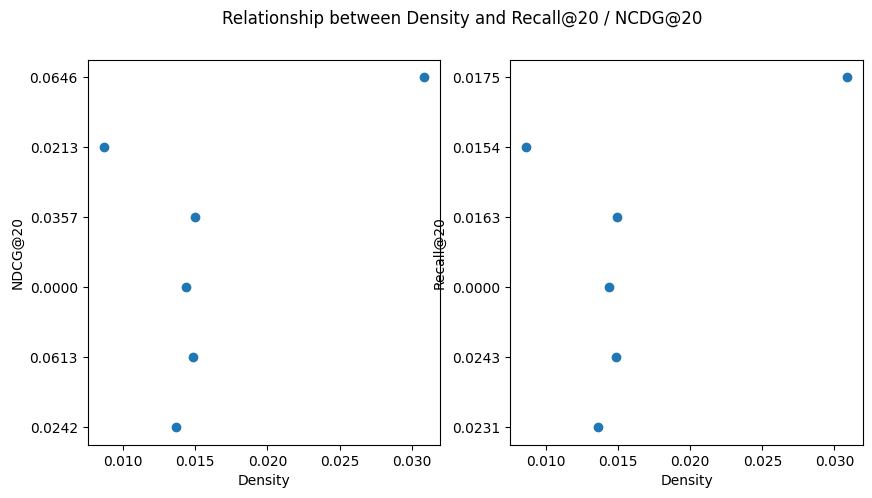

In [97]:
# relationship between density and ncdg@20
# corr between density and ncdg@20
density_ndcg_corr = df_kg_stats['Density'].corr(acc_comparison_df['NDCG@20'])
print(f"Correlation between Density and NCDG@20: {density_ndcg_corr:.4f}")
density_rec_corr = df_kg_stats['Density'].corr(acc_comparison_df['Recall@20'])
print(f"Correlation between Density and Recall@20: {density_rec_corr:.4f}")

fig, axs = plt.subplots(1,2, figsize=(10,5),dpi=100)
fig.suptitle('Relationship between Density and Recall@20 / NCDG@20')
axs[0].scatter(df_kg_stats['Density'], acc_comparison_df['NDCG@20'])
axs[0].set_xlabel('Density')
axs[0].set_ylabel('NDCG@20')

axs[1].scatter(df_kg_stats['Density'], acc_comparison_df['Recall@20'])
axs[1].set_xlabel('Density')
axs[1].set_ylabel('Recall@20')
plt.show()

Correlation between Average Degree and NCDG@20: 0.6514
Correlation between Average Degree and Recall@20: 0.0525


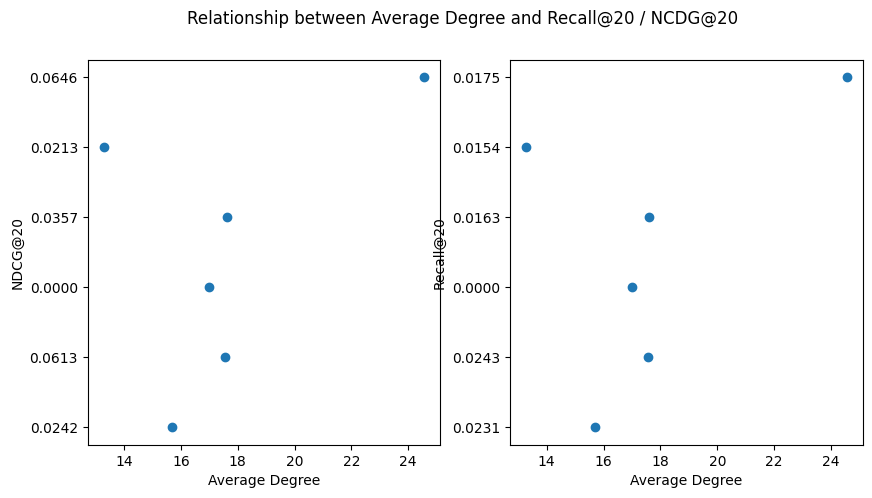

In [98]:
# relationship between avg degree and ncdg@20
avg_ndcg_corr = df_kg_stats['Average Degree'].corr(acc_comparison_df['NDCG@20'])
avg_rec_corr = df_kg_stats['Average Degree'].corr(acc_comparison_df['Recall@20'])

print(f"Correlation between Average Degree and NCDG@20: {avg_ndcg_corr:.4f}")
print(f"Correlation between Average Degree and Recall@20: {avg_rec_corr:.4f}")

fig, axs = plt.subplots(1,2, figsize=(10,5),dpi=100)
fig.suptitle('Relationship between Average Degree and Recall@20 / NCDG@20')
axs[0].scatter(df_kg_stats['Average Degree'], acc_comparison_df['NDCG@20'])
axs[0].set_xlabel('Average Degree')
axs[0].set_ylabel('NDCG@20')

axs[1].scatter(df_kg_stats['Average Degree'], acc_comparison_df['Recall@20'])
axs[1].set_xlabel('Average Degree')
axs[1].set_ylabel('Recall@20')
plt.show()


Correlation between Max Degree and Recall@20: 0.2036
Correlation between Max Degree and NCDG@20: 0.5592


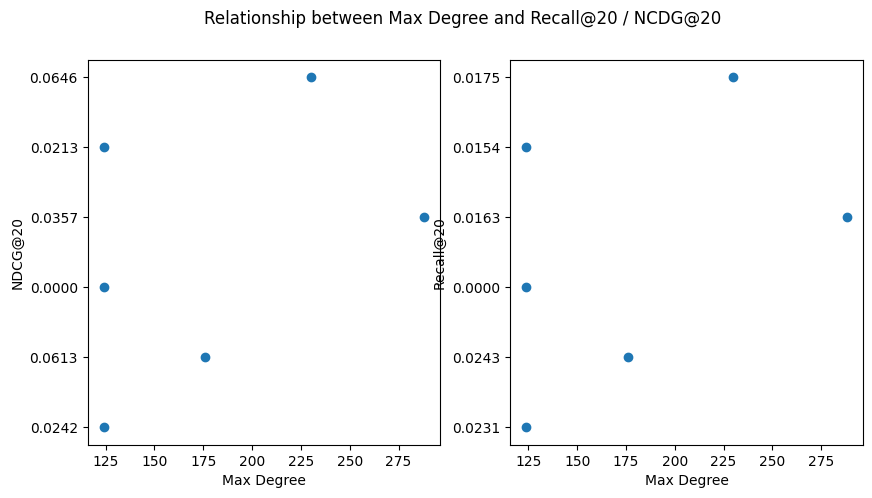

In [99]:
# relationship between max degree and recall@20
max_rec_corr = df_kg_stats['Max Degree'].corr(acc_comparison_df['Recall@20'])
print(f"Correlation between Max Degree and Recall@20: {max_rec_corr:.4f}")
max_ndcg_corr = df_kg_stats['Max Degree'].corr(acc_comparison_df['NDCG@20'])
print(f"Correlation between Max Degree and NCDG@20: {max_ndcg_corr:.4f}")

fig, axs = plt.subplots(1,2, figsize=(10,5),dpi=100)
fig.suptitle('Relationship between Max Degree and Recall@20 / NCDG@20')
axs[0].scatter(df_kg_stats['Max Degree'], acc_comparison_df['NDCG@20'])
axs[0].set_xlabel('Max Degree')
axs[0].set_ylabel('NDCG@20')

axs[1].scatter(df_kg_stats['Max Degree'], acc_comparison_df['Recall@20'])
axs[1].set_xlabel('Max Degree')
axs[1].set_ylabel('Recall@20')
plt.show()


## 4. Interpretation and Discussion